# QuPort end-to-end mapping, metrics, and cost

This notebook maps a random circuit onto a multi-QPU architecture, compares strategies, and visualizes trade-offs.

## Setup

In [1]:
import importlib.util
import subprocess
import sys

required = ['qiskit', 'matplotlib', 'pandas', 'numpy']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[viz,yaml,graph]'
    ])
'ready'

'ready'

## Build a multi-QPU configuration

In [2]:
from quport import LatencyModel, MultiQPUConfig

cfg = MultiQPUConfig(
    n_qpus=6,
    compute_qubits_per_qpu=6,
    comm_qubits_per_qpu=1,
    intra_topology='clique',
    inter_topology='switch',
)
cfg

MultiQPUConfig(n_qpus=6, compute_qubits_per_qpu=6, comm_qubits_per_qpu=1, intra_topology='clique', inter_topology='switch', inter_degree=2, link_capacity=1, switch_parallel_links=1000000, switch_reconfig_delay=0.0, async_classical=True, async_overlap=0.5, grid_rows=None, grid_cols=None, basis_gates=('rz', 'sx', 'x', 'cx'), optimization_level=3, layout_method='sabre', routing_method='sabre')

## Create a benchmark circuit

In [3]:
from quport.pipeline import random_benchmark_circuit

qc = random_benchmark_circuit(n_logical=30, depth=12, seed=7)
qc

## Map + transpile with multiple strategies

In [4]:
from quport.pipeline import map_and_transpile, transpile_baseline

latency = LatencyModel()
results = {
    'baseline': transpile_baseline(qc, cfg, latency=latency, seed=7),
    'balanced': map_and_transpile(qc, cfg, latency=latency, seed=7, strategy='balanced'),
    'tpccap': map_and_transpile(qc, cfg, latency=latency, seed=7, strategy='tpccap'),
    'tpccap_sa': map_and_transpile(qc, cfg, latency=latency, seed=7, strategy='tpccap_sa'),
}
{k: v.metrics for k, v in results.items()}

{'baseline': CircuitMetrics(swaps=0, depth=499, size=1265, n_1q=758, n_2q=507, remote_2q=174),
 'balanced': CircuitMetrics(swaps=0, depth=401, size=1227, n_1q=755, n_2q=472, remote_2q=158),
 'tpccap': CircuitMetrics(swaps=0, depth=497, size=1264, n_1q=768, n_2q=496, remote_2q=181),
 'tpccap_sa': CircuitMetrics(swaps=0, depth=463, size=1260, n_1q=776, n_2q=484, remote_2q=168)}

## Compare metrics and costs

In [5]:
import pandas as pd

rows = []
for name, res in results.items():
    rows.append({
        'strategy': name,
        'swaps': res.metrics.swaps,
        'remote_2q': res.metrics.remote_2q,
        'depth': res.metrics.depth,
        'cost_total': res.cost.total,
        'cost_local': res.cost.local,
        'cost_remote': res.cost.remote,
        'mapping_time_s': res.mapping_time_s,
        'transpile_time_s': res.transpile_time_s,
    })
df = pd.DataFrame(rows).sort_values('cost_total')
df

,strategy,swaps,remote_2q,depth,cost_total,cost_local,cost_remote,mapping_time_s,transpile_time_s
1,balanced,0,158,401,48536.0,5475.0,42660.0,0.002723,0.037346
3,tpccap_sa,0,168,463,51439.0,5616.0,45360.0,0.796006,0.038684
0,baseline,0,174,499,53307.0,5828.0,46980.0,0.000000,0.051038
2,tpccap,0,181,497,55095.0,5728.0,48870.0,0.112914,0.045656


## Visualize trade-offs

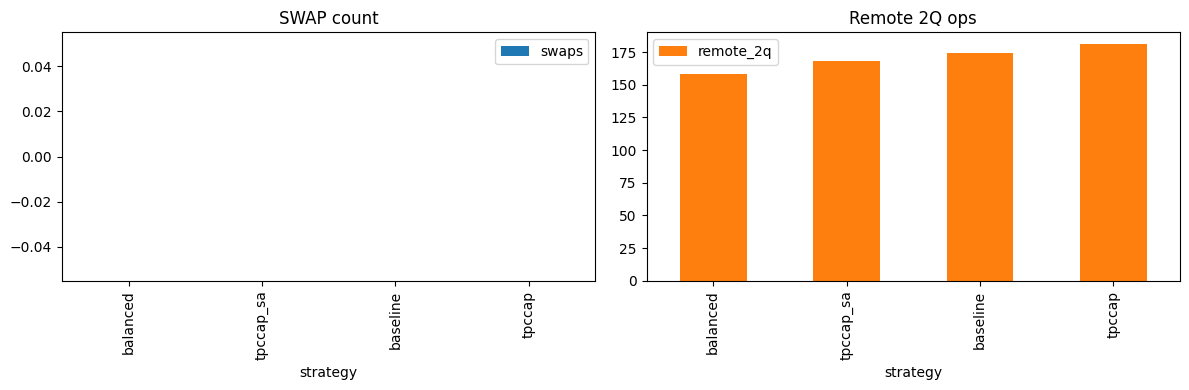

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.plot.bar(x='strategy', y='swaps', ax=axes[0], color='tab:blue', title='SWAP count')
df.plot.bar(x='strategy', y='remote_2q', ax=axes[1], color='tab:orange', title='Remote 2Q ops')
plt.tight_layout()
plt.show()

## Inspect the chosen partition

In [7]:
tpccap_res = results['tpccap_sa']
partition = tpccap_res.partition
partition[:20]

[2, 1, 3, 5, 4, 2, 5, 4, 3, 5, 3, 1, 4, 1, 0, 1, 2, 3, 2, 1]

## Visualize partition distribution

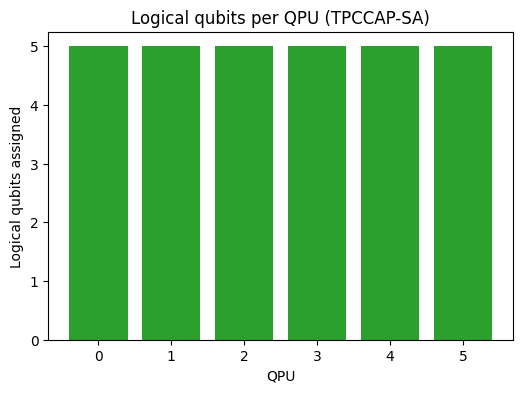

In [8]:
import numpy as np

counts = np.bincount(partition, minlength=cfg.n_qpus)
plt.figure(figsize=(6, 4))
plt.bar(range(cfg.n_qpus), counts, color='tab:green')
plt.title('Logical qubits per QPU (TPCCAP-SA)')
plt.xlabel('QPU')
plt.ylabel('Logical qubits assigned')
plt.show()